# 4.0 — Training Models (mỗi model chạy độc lập)

## Cấu trúc notebook

```
PHẦN 0 — Config chung (chạy 1 lần duy nhất)
├── 0A. Imports & GPU
├── 0B. Load data
├── 0C. Loss functions
└── 0D. Training engine

PHẦN 1 — CRAN              ← chạy độc lập
PHẦN 2 — ST-MSRN           ← chạy độc lập  
PHẦN 3 — DMLA-Net          ← chạy độc lập
PHẦN 4 — Bi-LSTM+Transformer ← chạy độc lập
PHẦN 5 — So sánh kết quả
```

> **Cách dùng:** Chạy Phần 0 trước. Sau đó chạy từng Phần (1/2/3/4) **độc lập**.
> Mỗi model có cell **Verify output** để kiểm tra trước khi train.


---
# PHẦN 0 — Config chung (chạy 1 lần)

## 0A. Imports & GPU

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
import json, pickle, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── GPU ──────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE   = torch.device('cuda')
    GPU_NAME = torch.cuda.get_device_name(0)
    VRAM_GB  = torch.cuda.get_device_properties(0).total_memory / 1e9
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True
    print(f'GPU  : {GPU_NAME}  ({VRAM_GB:.1f} GB VRAM)')
    print(f'CUDA : {torch.version.cuda}')
else:
    DEVICE = torch.device('cpu')
    print('CPU mode')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

SPLIT_DIR = Path('data/splits')
AUG_DIR   = Path('data/augmented')
MODEL_DIR = Path('models')
PLOT_DIR  = Path('data/plots')
MODEL_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

print(f'Device : {DEVICE}  |  PyTorch: {torch.__version__}')
print('Phần 0A OK')


GPU  : NVIDIA GeForce RTX 4060 Laptop GPU  (8.6 GB VRAM)
CUDA : 12.1
Device : cuda  |  PyTorch: 2.5.1+cu121
Phần 0A OK


## 0B. Load data & DataLoader

In [11]:
# ── Load config ───────────────────────────────────────────────────────────────
cfg    = json.loads((SPLIT_DIR / 'split_config.json').read_text())
dl_cfg = json.loads((AUG_DIR   / 'dataloader_config.json').read_text())

W          = cfg['window_size']       # 8
F_IN       = cfg['n_features']        # 27
N_HOR      = len(cfg['horizons_h'])   # 5
N_CLASS    = 7
HORIZONS_H = cfg['horizons_h']        # [6,12,24,48,72]
BATCH_SIZE = dl_cfg['batch_size']

print(f'W={W}  F_IN={F_IN}  N_HOR={N_HOR}  Batch={BATCH_SIZE}')

# ── Load arrays ───────────────────────────────────────────────────────────────
X_aug    = np.load(AUG_DIR   / 'train_X_aug.npy')
y_t_aug  = np.load(AUG_DIR   / 'train_y_track_aug.npy')
y_i_aug  = np.load(AUG_DIR   / 'train_y_intensity_aug.npy')
X_val    = np.load(SPLIT_DIR / 'val_X.npy')
y_t_val  = np.load(SPLIT_DIR / 'val_y_track.npy')
y_i_val  = np.load(SPLIT_DIR / 'val_y_intensity.npy')
X_test   = np.load(SPLIT_DIR / 'test_X.npy')
y_t_test = np.load(SPLIT_DIR / 'test_y_track.npy')
y_i_test = np.load(SPLIT_DIR / 'test_y_intensity.npy')

with open(SPLIT_DIR / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print(f'Train: {X_aug.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

# ── Dataset ───────────────────────────────────────────────────────────────────
class StormDataset(Dataset):
    def __init__(self, X, y_track, y_int):
        self.X  = torch.from_numpy(X).float()
        self.yt = torch.from_numpy(y_track).float()
        self.yw = torch.from_numpy(y_int[:, :, 0]).float()
        self.yp = torch.from_numpy(y_int[:, :, 1]).float()
        self.yc = torch.from_numpy(
            np.clip(y_int[:, :, 2], 0, 6).astype(np.int64)
        ).long()

    def __len__(self): return len(self.X)

    def __getitem__(self, i):
        return {
            'X'         : self.X[i],
            'y_track'   : self.yt[i],
            'y_wind'    : self.yw[i],
            'y_pressure': self.yp[i],
            'y_class'   : self.yc[i],
        }

# ── WeightedSampler (cap 3x) ──────────────────────────────────────────────────
cls_labels    = y_i_aug[:, 2, 2].astype(int).clip(0, 6)
classes, cnts = np.unique(cls_labels, return_counts=True)
raw_w = 1.0 / cnts.astype(float)
raw_w = raw_w / raw_w.min()
capped_w = np.minimum(raw_w, 3.0)
w_map = dict(zip(classes, capped_w))
s_w   = np.array([w_map.get(c, 1.0) for c in cls_labels], dtype=np.float32)
sampler = WeightedRandomSampler(torch.from_numpy(s_w), len(s_w), replacement=True)

PIN = (DEVICE.type == 'cuda')
NW  = 0
PF  = 2 if NW > 0 else None

train_loader = DataLoader(
    StormDataset(X_aug, y_t_aug, y_i_aug),
    batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NW, pin_memory=PIN,
    prefetch_factor=PF, persistent_workers=(NW>0), drop_last=True
)
val_loader = DataLoader(
    StormDataset(X_val, y_t_val, y_i_val),
    batch_size=BATCH_SIZE*2, shuffle=False,
    num_workers=NW, pin_memory=PIN,
    prefetch_factor=PF, persistent_workers=(NW>0)
)
test_loader = DataLoader(
    StormDataset(X_test, y_t_test, y_i_test),
    batch_size=BATCH_SIZE*2, shuffle=False,
    num_workers=NW, pin_memory=PIN,
    prefetch_factor=PF, persistent_workers=(NW>0)
)

STEPS = len(train_loader)
print(f'Train loader: {STEPS} steps/epoch')
print(f'Val   loader: {len(val_loader)} steps')
print('Phần 0B OK')


W=8  F_IN=27  N_HOR=5  Batch=64
Train: (13950, 8, 27)  Val: (344, 8, 27)  Test: (232, 8, 27)
Train loader: 217 steps/epoch
Val   loader: 3 steps
Phần 0B OK


## 0C. Loss Functions

In [12]:
# ── Haversine Loss ────────────────────────────────────────────────────────────
class HaversineLoss(nn.Module):
    """MAE theo km thực tế từ Δlat, Δlon."""
    def __init__(self, per_horizon=False, R=6371.0):
        super().__init__()
        self.R = R
        self.per_horizon = per_horizon

    def forward(self, pred, target):
        """pred, target: [B, H, 2]"""
        dlat = torch.deg2rad(pred[:,:,0] - target[:,:,0])
        dlon = torch.deg2rad(pred[:,:,1] - target[:,:,1])
        lat1 = torch.deg2rad(target[:,:,0])
        lat2 = torch.deg2rad(pred[:,:,0])
        a    = (torch.sin(dlat/2)**2
                + torch.cos(lat1)*torch.cos(lat2)*torch.sin(dlon/2)**2)
        d    = 2 * self.R * torch.arcsin(torch.sqrt(a.clamp(0, 1)))  # [B, H]
        return d.mean(dim=0) if self.per_horizon else d.mean()


# ── Focal Loss + Label Smoothing ──────────────────────────────────────────────
class FocalLossSmooth(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1, weight=None):
        super().__init__()
        self.gamma    = gamma
        self.smoothing= smoothing
        self.weight   = weight

    def forward(self, logits, targets):
        """logits: [B,H,C]  targets: [B,H] long"""
        B, H, C = logits.shape
        lp      = F.log_softmax(logits.reshape(-1, C), dim=-1)
        t_flat  = targets.reshape(-1)
        with torch.no_grad():
            smooth = torch.full_like(lp, self.smoothing / (C-1))
            smooth.scatter_(1, t_flat.unsqueeze(1), 1.0 - self.smoothing)
        ce    = -(smooth * lp).sum(dim=-1)
        p_t   = torch.exp(-F.nll_loss(lp, t_flat,
                                       weight=self.weight, reduction='none'))
        return (((1-p_t)**self.gamma) * ce).mean()


# ── Normalized Multi-Task Loss ────────────────────────────────────────────────
class MultiTaskLoss(nn.Module):
    """
    Normalize về cùng scale ~0.5-1.5:
      track_loss    = Haversine / 100
      wind_loss     = Huber(wind/10)
      pressure_loss = Huber(pres/50)
      class_loss    = FocalSmooth

    Input pred dict cần có ĐÚNG 4 keys:
      'track'        [B, H, 2]
      'wind'         [B, H]
      'pressure'     [B, H]
      'class_logits' [B, H, 7]
    """
    REQUIRED_KEYS = {'track', 'wind', 'pressure', 'class_logits'}

    def __init__(self, w_t=1.0, w_w=1.0, w_p=0.5, w_c=1.0,
                 class_weights=None, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.w_t = w_t; self.w_w = w_w; self.w_p = w_p; self.w_c = w_c
        self.hav   = HaversineLoss()
        self.hub_w = nn.HuberLoss(delta=1.0)
        self.hub_p = nn.HuberLoss(delta=1.0)
        self.focal = FocalLossSmooth(gamma, smoothing, class_weights)

    def forward(self, pred: dict, batch: dict) -> dict:
        # ── Kiểm tra keys (giúp debug nhanh) ─────────────────────────────────
        missing = self.REQUIRED_KEYS - set(pred.keys())
        if missing:
            raise KeyError(
                f"Model thiếu keys: {missing}\n"
                f"Model đang trả về: {set(pred.keys())}\n"
                f"→ Kiểm tra hàm forward() của model!"
            )

        dev  = pred['track'].device
        l_t  = self.hav(pred['track'], batch['y_track'].to(dev)) / 100.0
        l_w  = self.hub_w(pred['wind'] / 10.0,
                          batch['y_wind'].to(dev) / 10.0)
        l_p  = self.hub_p(pred['pressure'] / 50.0,
                          batch['y_pressure'].to(dev) / 50.0)
        l_c  = self.focal(pred['class_logits'], batch['y_class'].to(dev))
        tot  = self.w_t*l_t + self.w_w*l_w + self.w_p*l_p + self.w_c*l_c
        return {
            'total'      : tot,
            'track_norm' : l_t.detach(),
            'wind_norm'  : l_w.detach(),
            'pres_norm'  : l_p.detach(),
            'class'      : l_c.detach(),
        }


# Class weights
cls_w_arr  = np.array([capped_w[list(classes).index(c)] if c in classes else 1.0
                       for c in range(7)], dtype=np.float32)
cls_w_arr /= cls_w_arr.sum()
CLASS_WEIGHTS = torch.from_numpy(cls_w_arr).to(DEVICE)

criterion = MultiTaskLoss(
    w_t=1.0, w_w=1.0, w_p=0.5, w_c=1.0,
    class_weights=CLASS_WEIGHTS, gamma=2.0, smoothing=0.1
)

# Haversine per-horizon để log
hav_per_h = HaversineLoss(per_horizon=True)

print('Criterion: MultiTaskLoss OK')
print('  Required keys:', MultiTaskLoss.REQUIRED_KEYS)
print('Phần 0C OK')


Criterion: MultiTaskLoss OK
  Required keys: {'pressure', 'wind', 'track', 'class_logits'}
Phần 0C OK


## 0D. Training Engine & Shared Heads

In [13]:
# ── Shared Output Heads ───────────────────────────────────────────────────────
class OutputHeads(nn.Module):
    """
    Output heads dùng chung cho mọi model.
    Input : ctx [B, d_model]
    Output: dict với ĐÚNG 4 keys:
        'track'        [B, H, 2]
        'wind'         [B, H]
        'pressure'     [B, H]
        'class_logits' [B, H, 7]
    """
    def __init__(self, d_model: int, n_hor: int, n_cls: int, drop: float = 0.2):
        super().__init__()
        self.H = n_hor
        self.C = n_cls
        self.norm  = nn.LayerNorm(d_model)
        self.proj  = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(drop),
        )
        self.head_track = nn.Linear(d_model, n_hor * 2)
        self.head_wind  = nn.Linear(d_model, n_hor)
        self.head_pres  = nn.Linear(d_model, n_hor)
        self.head_cls   = nn.Linear(d_model, n_hor * n_cls)

    def forward(self, ctx: torch.Tensor) -> dict:
        ctx = self.proj(self.norm(ctx))
        return {
            'track'        : self.head_track(ctx).view(-1, self.H, 2),
            'wind'         : self.head_wind(ctx),
            'pressure'     : self.head_pres(ctx),
            'class_logits' : self.head_cls(ctx).view(-1, self.H, self.C),
        }


# ── Verify helper ─────────────────────────────────────────────────────────────
def verify_model_output(model: nn.Module, name: str = '') -> bool:
    """
    Chạy 1 forward pass với dummy data.
    Kiểm tra output có đúng 4 keys và shapes không.
    Return True nếu OK, raise nếu lỗi.
    """
    print(f'=== Verify model: {name or model.__class__.__name__} ===')
    model.eval()
    x_dummy = torch.randn(4, W, F_IN)

    with torch.no_grad():
        out = model(x_dummy)

    print(f'  Output type: {type(out)}')
    print(f'  Keys       : {set(out.keys())}')

    expected = {'track', 'wind', 'pressure', 'class_logits'}
    missing  = expected - set(out.keys())
    extra    = set(out.keys()) - expected

    if missing:
        raise KeyError(f'Thiếu keys: {missing} — kiểm tra forward()!')
    if extra:
        print(f'  ⚠ Keys thừa (không dùng): {extra}')

    shapes = {
        'track'        : (4, N_HOR, 2),
        'wind'         : (4, N_HOR),
        'pressure'     : (4, N_HOR),
        'class_logits' : (4, N_HOR, N_CLASS),
    }
    all_ok = True
    for k, expected_shape in shapes.items():
        actual = tuple(out[k].shape)
        ok     = actual == expected_shape
        status = '✓' if ok else '✗'
        print(f'  {status} {k:<14}: {str(actual):<20} (expected {expected_shape})')
        if not ok:
            all_ok = False

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  Params: {n_params:.2f}M')

    if all_ok:
        print('  → Model OK! Sẵn sàng train.')
    else:
        raise ValueError('Shapes không đúng — kiểm tra OutputHeads!')
    return True


# ── Training & Evaluation ─────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot = {'total':0,'track_norm':0,'wind_norm':0,'pres_norm':0,'class':0}
    per_h = torch.zeros(N_HOR)
    n = 0
    for batch in loader:
        x    = batch['X'].to(DEVICE, non_blocking=True)
        pred = model(x)
        ls   = criterion(pred, batch)
        for k in tot:
            tot[k] += ls[k].item()
        per_h += hav_per_h(pred['track'].cpu(), batch['y_track']).detach()
        n += 1
    result = {k: v/n for k, v in tot.items()}
    per_h /= n
    for i, h in enumerate(HORIZONS_H):
        result[f't{h}h_km'] = float(per_h[i])
    return result


def train_one_epoch(model, optimizer, scaler):
    model.train()
    tot = {'total':0,'track_norm':0,'wind_norm':0,'pres_norm':0,'class':0}
    n = 0
    for batch in train_loader:
        x = batch['X'].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE.type=='cuda')):
            pred = model(x)
            ls   = criterion(pred, batch)
        scaler.scale(ls['total']).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        for k in tot:
            tot[k] += ls[k].item()
        n += 1
    return {k: v/n for k, v in tot.items()}


def run_training(
    model,
    model_name:     str,
    n_epochs:       int   = 150,
    lr:             float = 1e-4,
    patience:       int   = 25,
    warmup_epochs:  int   = 5,
    T0:             int   = 20,
) -> dict:
    """
    Full training loop cho 1 model:
    - Linear warmup 5 epoch
    - CosineAnnealingWarmRestarts sau warmup
    - Mixed Precision AMP
    - Early stopping (patience=25)
    - Checkpoint lưu model tốt nhất
    """
    # Verify output trước khi train
    verify_model_output(model, model_name)
    print()

    model.to(DEVICE)
    ckpt_path = MODEL_DIR / f'{model_name.replace("+","_").replace("-","_")}_best.pt'

    # AdamW
    decay = [p for n,p in model.named_parameters() if p.requires_grad and p.ndim >= 2]
    nodec = [p for n,p in model.named_parameters() if p.requires_grad and p.ndim <  2]
    opt   = torch.optim.AdamW(
        [{'params': decay, 'weight_decay': 1e-4},
         {'params': nodec, 'weight_decay': 0.0}],
        lr=lr
    )

    # Schedulers
    warmup_sched = torch.optim.lr_scheduler.LinearLR(
        opt, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
    )
    cosine_sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=T0, T_mult=1, eta_min=1e-6
    )

    scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))

    # History
    hist = {
        'train_total': [], 'val_total': [], 'val_class': [],
        'lr': [],
        **{f't{h}h_km': [] for h in HORIZONS_H}
    }
    best_val   = float('inf')
    bad_epochs = 0
    best_state = None
    t_start    = time.time()

    print(f'Training {model_name} | {n_epochs} epochs | lr={lr} | patience={patience}')
    print(f'Checkpoint → {ckpt_path}')
    print(f'{"─"*78}')
    hdr = (f'{"Ep":>5}  {"Train":>7}  {"Val":>7}  '
           f'{"t+6h":>7}  {"t+24h":>7}  {"t+72h":>7}  '
           f'{"LR":>9}  {"Time":>6}')
    print(hdr)
    print(f'{"─"*78}')

    for ep in range(1, n_epochs + 1):
        tr = train_one_epoch(model, opt, scaler)
        vl = evaluate(model, val_loader)

        # Scheduler
        if ep <= warmup_epochs:
            warmup_sched.step()
        else:
            cosine_sched.step(ep - warmup_epochs)

        cur_lr = opt.param_groups[0]['lr']

        # Log
        hist['train_total'].append(tr['total'])
        hist['val_total'  ].append(vl['total'])
        hist['val_class'  ].append(vl['class'])
        hist['lr'         ].append(cur_lr)
        for h in HORIZONS_H:
            hist[f't{h}h_km'].append(vl[f't{h}h_km'])

        # Early stopping
        if vl['total'] < best_val:
            best_val   = vl['total']
            bad_epochs = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save({
                'epoch'      : ep,
                'model_state': best_state,
                'val_total'  : best_val,
                'per_horizon': {f't+{h}h': vl[f't{h}h_km'] for h in HORIZONS_H},
                'model_name' : model_name,
            }, ckpt_path)
        else:
            bad_epochs += 1

        # Print mỗi epoch
        tag  = ' [WU]' if ep <= warmup_epochs else '      '
        mins = (time.time() - t_start) / 60
        print(
            f'{ep:5d}{tag} '
            f'{tr["total"]:7.4f}  {vl["total"]:7.4f}  '
            f'{vl["t6h_km"]:7.1f}  {vl["t24h_km"]:7.1f}  {vl["t72h_km"]:7.1f}  '
            f'{cur_lr:9.2e}  {mins:5.1f}m'
            + (' ← best' if bad_epochs == 0 else f'  ({bad_epochs} no improve)')
        )

        if bad_epochs >= patience:
            print(f'Early stop tại epoch {ep}')
            break

    # Load best
    if best_state:
        model.load_state_dict(best_state)

    t_total = (time.time() - t_start) / 60
    print('─' * 78)
    print(f'Xong! Best val={best_val:.4f} | Epochs={len(hist["train_total"])} | Time={t_total:.1f}min')
    print()

    # Print per-horizon summary
    print('Track MAE theo horizon (best epoch):')
    for h in HORIZONS_H:
        best_h = min(hist[f't{h}h_km'])
        print(f'  t+{h:2d}h: {best_h:.1f} km')

    hist['best_val']       = best_val
    hist['total_time_min'] = t_total
    hist['model_name']     = model_name
    return hist


# Dict lưu kết quả tất cả models
ALL_RESULTS = {}

print('Training engine OK')
print('Hàm verify_model_output() sẽ kiểm tra keys & shapes trước khi train')
print('Phần 0D OK — Sẵn sàng train từng model!')
print()
print('Tiếp theo: chạy Phần 1 (CRAN) hoặc bất kỳ phần nào bạn muốn.')


Training engine OK
Hàm verify_model_output() sẽ kiểm tra keys & shapes trước khi train
Phần 0D OK — Sẵn sàng train từng model!

Tiếp theo: chạy Phần 1 (CRAN) hoặc bất kỳ phần nào bạn muốn.


---
# PHẦN 1 — CRAN (Conv-Retention Adaptive Network)

> Chạy **sau** Phần 0. Có thể re-run độc lập bất kỳ lúc nào.


In [14]:
# ── CRAN Definition ───────────────────────────────────────────────────────────

class ConvBlock(nn.Module):
    """Depthwise-Separable Conv1D + PreNorm + Residual."""
    def __init__(self, d: int, kernel: int = 3, drop: float = 0.1):
        super().__init__()
        self.prenorm = nn.LayerNorm(d)
        self.dw      = nn.Conv1d(d, d, kernel, padding=kernel//2, groups=d)
        self.pw      = nn.Conv1d(d, d, 1)
        self.act     = nn.GELU()
        self.drop    = nn.Dropout(drop)
        self.postnorm= nn.LayerNorm(d)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: [B, W, d]"""
        r  = x
        xn = self.prenorm(x).transpose(1, 2)          # [B, d, W]
        o  = self.drop(self.act(self.pw(self.dw(xn)))).transpose(1, 2)  # [B, W, d]
        return self.postnorm(o + r)


class RetentionBlock(nn.Module):
    """Gated Recurrent Retention + PreNorm + FFN."""
    def __init__(self, d: int, gamma: float = 0.9, drop: float = 0.1):
        super().__init__()
        self.gamma   = gamma
        self.prenorm = nn.LayerNorm(d)
        self.Wq  = nn.Linear(d, d)
        self.Wk  = nn.Linear(d, d)
        self.Wv  = nn.Linear(d, d)
        self.Wg  = nn.Linear(d, d)   # gate
        self.out = nn.Linear(d, d)
        self.norm_ret = nn.LayerNorm(d)
        self.ffn = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d*2), nn.GELU(), nn.Dropout(drop),
            nn.Linear(d*2, d),
        )
        self.norm_ffn = nn.LayerNorm(d)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: [B, W, d]"""
        B, W, D = x.shape
        xn = self.prenorm(x)
        Q  = self.Wq(xn); K = self.Wk(xn)
        V  = self.Wv(xn); g = torch.sigmoid(self.Wg(xn))

        # Recurrent retention state
        s    = torch.zeros(B, D, D, device=x.device)
        outs = []
        for t in range(W):
            s = (self.gamma * s
                 + torch.bmm(
                     K[:, t, :].unsqueeze(2),
                     V[:, t, :].unsqueeze(1)
                 )).clamp(-10, 10)               # stable
            r = torch.bmm(Q[:, t, :].unsqueeze(1), s).squeeze(1)
            outs.append(r)

        ret = g * torch.stack(outs, dim=1)      # gated  [B, W, D]
        ret = self.norm_ret(self.out(ret) + x)  # residual
        return self.norm_ffn(self.ffn(ret) + ret)


class AdaptiveFusion(nn.Module):
    """Học α per-position: out = α·conv + (1-α)·retention."""
    def __init__(self, d: int):
        super().__init__()
        self.gate = nn.Linear(d*2, d)
        self.norm = nn.LayerNorm(d)

    def forward(self, c: torch.Tensor, r: torch.Tensor) -> torch.Tensor:
        a = torch.sigmoid(self.gate(torch.cat([c, r], dim=-1)))
        return self.norm(a * c + (1-a) * r)


class CRAN(nn.Module):
    """
    CRAN: Conv-Retention Adaptive Network

    Conv block    → local pattern (6-12h)
    Retention     → global sequence dependency
    AdaptiveFusion→ learnable weighting per timestep
    """
    def __init__(
        self,
        f_in    : int   = 27,
        d_model : int   = 128,
        n_layers: int   = 2,
        n_hor   : int   = 5,
        n_cls   : int   = 7,
        gamma   : float = 0.9,
        drop    : float = 0.2,
    ):
        super().__init__()

        self.input_proj = nn.Linear(f_in, d_model)

        self.conv_blocks  = nn.ModuleList([
            ConvBlock(d_model, kernel=3, drop=drop) for _ in range(n_layers)
        ])
        self.ret_blocks   = nn.ModuleList([
            RetentionBlock(d_model, gamma=gamma, drop=drop) for _ in range(n_layers)
        ])
        self.fusions      = nn.ModuleList([
            AdaptiveFusion(d_model) for _ in range(n_layers)
        ])

        # Context: concat(last_step, mean_pool) → d_model*2
        self.ctx_proj = nn.Sequential(
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, d_model * 2),
            nn.GELU(),
            nn.Dropout(drop),
        )

        self.heads = OutputHeads(d_model * 2, n_hor, n_cls, drop)

    def forward(self, x: torch.Tensor) -> dict:
        """x: [B, W, F_IN] → dict với 4 keys"""
        h = self.input_proj(x)   # [B, W, d]

        for conv, ret, fuse in zip(self.conv_blocks, self.ret_blocks, self.fusions):
            c = conv(h)
            r = ret(h)
            h = fuse(c, r)        # [B, W, d]

        # Context vector
        ctx = self.ctx_proj(
            torch.cat([h[:, -1, :], h.mean(dim=1)], dim=-1)
        )   # [B, d*2]

        return self.heads(ctx)   # dict: track, wind, pressure, class_logits


print('CRAN defined OK')


CRAN defined OK


In [15]:
# ── Verify CRAN output ────────────────────────────────────────────────────────
cran_model = CRAN(
    f_in=F_IN, d_model=128, n_layers=2,
    n_hor=N_HOR, n_cls=N_CLASS, gamma=0.9, drop=0.2
)
verify_model_output(cran_model, 'CRAN')


=== Verify model: CRAN ===
  Output type: <class 'dict'>
  Keys       : {'pressure', 'wind', 'track', 'class_logits'}
  ✓ track         : (4, 5, 2)            (expected (4, 5, 2))
  ✓ wind          : (4, 5)               (expected (4, 5))
  ✓ pressure      : (4, 5)               (expected (4, 5))
  ✓ class_logits  : (4, 5, 7)            (expected (4, 5, 7))
  Params: 0.55M
  → Model OK! Sẵn sàng train.


True

In [16]:
# ── Train CRAN ────────────────────────────────────────────────────────────────
cran_hist = run_training(
    model       = cran_model,
    model_name  = 'CRAN',
    n_epochs    = 150,
    lr          = 1e-4,
    patience    = 25,
    warmup_epochs=5,
    T0          = 20,
)
ALL_RESULTS['CRAN'] = cran_hist


=== Verify model: CRAN ===
  Output type: <class 'dict'>
  Keys       : {'pressure', 'wind', 'track', 'class_logits'}
  ✓ track         : (4, 5, 2)            (expected (4, 5, 2))
  ✓ wind          : (4, 5)               (expected (4, 5))
  ✓ pressure      : (4, 5)               (expected (4, 5))
  ✓ class_logits  : (4, 5, 7)            (expected (4, 5, 7))
  Params: 0.55M
  → Model OK! Sẵn sàng train.

Training CRAN | 150 epochs | lr=0.0001 | patience=25
Checkpoint → models\CRAN_best.pt
──────────────────────────────────────────────────────────────────────────────
   Ep    Train      Val     t+6h    t+24h    t+72h         LR    Time
──────────────────────────────────────────────────────────────────────────────
    1 [WU]  0.7596   0.7938     42.7     67.0    112.2   2.80e-04    0.1m ← best
    2 [WU]  0.5909   0.8185     41.3     70.0    120.2   4.60e-04    0.2m  (1 no improve)
    3 [WU]  0.5011   0.8160     41.3     70.8    117.6   6.40e-04    0.3m  (2 no improve)
    4 [WU]  0.4481

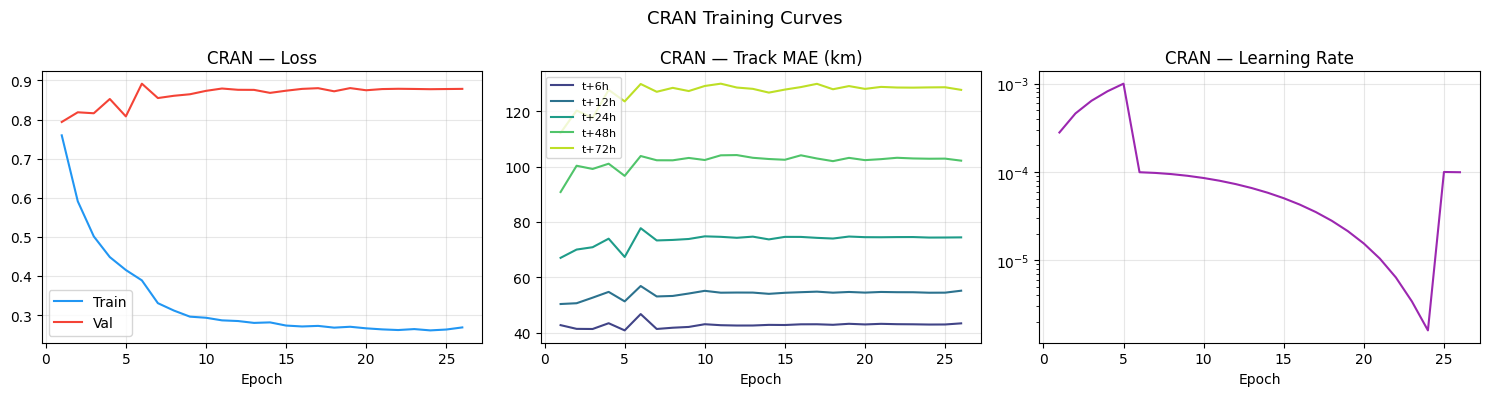

CRAN training complete!


In [17]:
# ── Plot CRAN training curve ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ep = range(1, len(cran_hist['train_total'])+1)
axes[0].plot(ep, cran_hist['train_total'], label='Train', color='#2196F3')
axes[0].plot(ep, cran_hist['val_total'],   label='Val',   color='#F44336')
axes[0].set_title('CRAN — Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

colors_h = plt.cm.viridis(np.linspace(0.2, 0.9, N_HOR))
for i, h in enumerate(HORIZONS_H):
    axes[1].plot(ep, cran_hist[f't{h}h_km'],
                 label=f't+{h}h', color=colors_h[i])
axes[1].set_title('CRAN — Track MAE (km)'); axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(ep, cran_hist['lr'], color='#9C27B0')
axes[2].set_title('CRAN — Learning Rate')
axes[2].set_xlabel('Epoch'); axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

plt.suptitle('CRAN Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR/'p1_cran_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('CRAN training complete!')


---
# PHẦN 2 — ST-MSRN (Spatio-Temporal Multi-Scale Retention Network)


In [18]:
# ── ST-MSRN Definition ────────────────────────────────────────────────────────

class RetentionLayerMSRN(nn.Module):
    """Multi-scale Retention: mỗi head có decay rate γ khác nhau."""
    def __init__(self, d_in: int, d_out: int, n_heads: int = 4):
        super().__init__()
        assert d_out % n_heads == 0
        self.H   = n_heads
        self.Dh  = d_out // n_heads
        self.norm= nn.LayerNorm(d_in)
        self.Wq  = nn.Linear(d_in, d_out)
        self.Wk  = nn.Linear(d_in, d_out)
        self.Wv  = nn.Linear(d_in, d_out)
        self.out = nn.Linear(d_out, d_out)
        self.out_norm = nn.LayerNorm(d_out)
        # γ_i = 1 - 2^(-5 - i)  →  decay khác nhau per head
        gammas = 1 - 2 ** (-5 - torch.arange(n_heads).float())
        self.register_buffer('gammas', gammas)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, W, _ = x.shape
        H, Dh   = self.H, self.Dh
        xn = self.norm(x)
        Q  = self.Wq(xn).view(B, W, H, Dh).transpose(1, 2)  # [B,H,W,Dh]
        K  = self.Wk(xn).view(B, W, H, Dh).transpose(1, 2)
        V  = self.Wv(xn).view(B, W, H, Dh).transpose(1, 2)

        idx  = torch.arange(W, device=x.device)
        diff = (idx.unsqueeze(0) - idx.unsqueeze(1)).abs()    # [W,W]
        D    = torch.tril(self.gammas.view(H,1,1) ** diff)    # [H,W,W]

        attn = torch.matmul(Q, K.transpose(-1,-2)) * D.unsqueeze(0)  # [B,H,W,W]
        attn = attn / (attn.abs().sum(-1, keepdim=True) + 1e-6)
        out  = torch.matmul(attn, V)                          # [B,H,W,Dh]
        out  = out.transpose(1,2).contiguous().view(B, W, -1)
        return self.out_norm(self.out(out))


class ST_MSRN(nn.Module):
    """
    ST-MSRN: 3 nhánh song song
    A: Short-term  — Conv1D local window
    B: Mid-term    — Multi-scale Retention
    C: Compressed  — AvgPool → Retention → Upsample
    """
    def __init__(
        self,
        f_in    : int   = 27,
        d_branch: int   = 64,
        d_model : int   = 256,
        n_hor   : int   = 5,
        n_cls   : int   = 7,
        n_rh    : int   = 4,
        drop    : float = 0.2,
    ):
        super().__init__()
        d = d_branch

        # ── Branch A: Short-term Conv ────────────────────────────────────────
        self.a_norm = nn.LayerNorm(f_in)
        self.a_conv = nn.Sequential(
            nn.Conv1d(f_in, d, kernel_size=3, padding=1), nn.GELU(),
            nn.Conv1d(d,    d, kernel_size=3, padding=1), nn.GELU(),
        )
        self.a_skip  = nn.Linear(f_in, d)
        self.a_out   = nn.LayerNorm(d)

        # ── Branch B: Mid-term Retention ────────────────────────────────────
        self.b_proj  = nn.Sequential(nn.LayerNorm(f_in), nn.Linear(f_in, d), nn.GELU())
        self.b_ret   = RetentionLayerMSRN(d, d, n_heads=n_rh)
        self.b_out   = nn.LayerNorm(d)

        # ── Branch C: Compressed Memory ──────────────────────────────────────
        self.c_pool  = nn.AvgPool1d(kernel_size=2, stride=2)
        self.c_proj  = nn.Linear(f_in, d)
        self.c_ret   = RetentionLayerMSRN(d, d, n_heads=n_rh)
        self.c_out   = nn.LayerNorm(d)

        # ── Fusion ───────────────────────────────────────────────────────────
        self.fuse = nn.Sequential(
            nn.LayerNorm(d * 3),
            nn.Linear(d*3, d_model), nn.GELU(), nn.Dropout(drop),
            nn.Linear(d_model, d_model), nn.GELU(),
        )

        self.heads = OutputHeads(d_model, n_hor, n_cls, drop)

    def forward(self, x: torch.Tensor) -> dict:
        B, W, _ = x.shape

        # Branch A
        xn = self.a_norm(x).transpose(1, 2)              # [B, F, W]
        a  = self.a_conv(xn).transpose(1, 2)              # [B, W, d]
        a  = self.a_out(a + self.a_skip(x))

        # Branch B
        b_in = self.b_proj(x)                             # [B, W, d]
        b    = self.b_out(self.b_ret(b_in) + b_in)

        # Branch C
        c_pool = self.c_pool(x.transpose(1,2)).transpose(1,2)   # [B, W//2, F]
        c_proj = self.c_proj(c_pool)                             # [B, W//2, d]
        c_ret  = self.c_ret(c_proj)                              # [B, W//2, d]
        c_up   = F.interpolate(
            c_ret.transpose(1,2), size=W, mode='linear', align_corners=False
        ).transpose(1,2)                                         # [B, W, d]
        c = self.c_out(c_up)

        # Fusion: last timestep
        fused = torch.cat([a, b, c], dim=-1)  # [B, W, 3d]
        ctx   = self.fuse(fused[:, -1, :])    # [B, d_model]

        return self.heads(ctx)   # dict: track, wind, pressure, class_logits


print('ST-MSRN defined OK')


ST-MSRN defined OK


In [19]:
stmsrn_model = ST_MSRN(
    f_in=F_IN, d_branch=64, d_model=256,
    n_hor=N_HOR, n_cls=N_CLASS, n_rh=4, drop=0.2
)
verify_model_output(stmsrn_model, 'ST-MSRN')


=== Verify model: ST-MSRN ===
  Output type: <class 'dict'>
  Keys       : {'pressure', 'wind', 'track', 'class_logits'}
  ✓ track         : (4, 5, 2)            (expected (4, 5, 2))
  ✓ wind          : (4, 5)               (expected (4, 5))
  ✓ pressure      : (4, 5)               (expected (4, 5))
  ✓ class_logits  : (4, 5, 7)            (expected (4, 5, 7))
  Params: 0.25M
  → Model OK! Sẵn sàng train.


True

In [21]:
stmsrn_hist = run_training(
    model       = stmsrn_model,
    model_name  = 'ST-MSRN',
    n_epochs    = 150, lr=1e-4, patience=25,
    warmup_epochs=5, T0=20,
)
ALL_RESULTS['ST-MSRN'] = stmsrn_hist


=== Verify model: ST-MSRN ===


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument weight in method wrapper_CUDA__native_layer_norm)

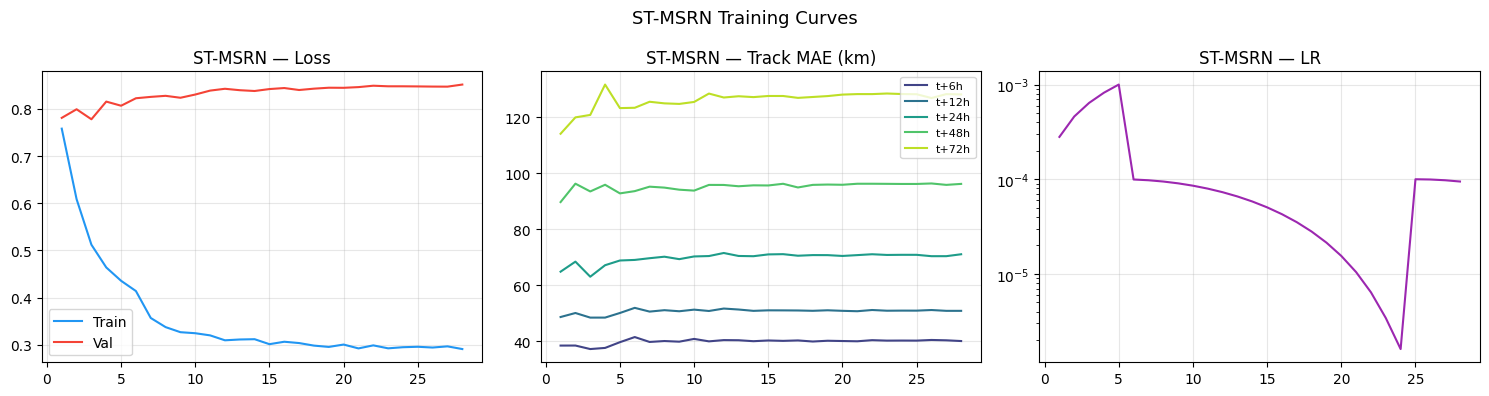

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(stmsrn_hist['train_total'])+1)
axes[0].plot(ep, stmsrn_hist['train_total'], label='Train', color='#2196F3')
axes[0].plot(ep, stmsrn_hist['val_total'],   label='Val',   color='#F44336')
axes[0].set_title('ST-MSRN — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

colors_h = plt.cm.viridis(np.linspace(0.2, 0.9, N_HOR))
for i, h in enumerate(HORIZONS_H):
    axes[1].plot(ep, stmsrn_hist[f't{h}h_km'], label=f't+{h}h', color=colors_h[i])
axes[1].set_title('ST-MSRN — Track MAE (km)'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(ep, stmsrn_hist['lr'], color='#9C27B0')
axes[2].set_title('ST-MSRN — LR'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)
plt.suptitle('ST-MSRN Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR/'p2_stmsrn_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
# PHẦN 3 — DMLA-Net (Dual Memory Linear Attention)

In [23]:
# ── DMLA-Net Definition ───────────────────────────────────────────────────────

class LinearAttention(nn.Module):
    """Linear Attention O(N·d²) với feature map φ(x)=ELU(x)+1."""
    def __init__(self, d: int, n_heads: int = 4):
        super().__init__()
        assert d % n_heads == 0
        self.H  = n_heads
        self.Dh = d // n_heads
        self.norm = nn.LayerNorm(d)
        self.Wq   = nn.Linear(d, d); self.Wk = nn.Linear(d, d)
        self.Wv   = nn.Linear(d, d); self.out = nn.Linear(d, d)
        self.out_norm = nn.LayerNorm(d)

    @staticmethod
    def _phi(t):
        return F.elu(t).clamp(min=0.0) + 1.0   # luôn dương

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, W, _ = x.shape
        H, Dh   = self.H, self.Dh
        xn = self.norm(x)
        Q  = self._phi(self.Wq(xn).view(B, W, H, Dh).transpose(1, 2))  # [B,H,W,Dh]
        K  = self._phi(self.Wk(xn).view(B, W, H, Dh).transpose(1, 2))
        V  = self.Wv(xn).view(B, W, H, Dh).transpose(1, 2)

        KV    = torch.matmul(K.transpose(-1,-2), V)               # [B,H,Dh,Dh]
        out   = torch.matmul(Q, KV)                               # [B,H,W,Dh]
        k_sum = K.sum(dim=2, keepdim=True)                        # [B,H,1,Dh]
        denom = (Q * k_sum).sum(dim=-1, keepdim=True).clamp(min=1e-4)
        out   = (out / denom).transpose(1,2).contiguous().view(B, W, -1)
        return self.out_norm(self.out(out))


class DMLA_Net(nn.Module):
    """
    DMLA-Net: Dual Memory Linear Attention Network
    Local  memory: Conv1D  → pattern ngắn hạn
    Global memory: LinearAttn → context dài
    GRU: tích hợp 2 luồng theo thứ tự thời gian
    """
    def __init__(
        self,
        f_in   : int   = 27,
        d_loc  : int   = 128,
        d_glb  : int   = 128,
        d_gru  : int   = 256,
        n_hor  : int   = 5,
        n_cls  : int   = 7,
        n_heads: int   = 4,
        drop   : float = 0.2,
    ):
        super().__init__()

        # Local: Conv1D depthwise-separable
        self.loc_norm= nn.LayerNorm(f_in)
        self.loc_dw  = nn.Conv1d(f_in, f_in, 3, padding=1, groups=f_in)
        self.loc_pw  = nn.Conv1d(f_in, d_loc, 1)
        self.loc_act = nn.GELU()
        self.loc_drop= nn.Dropout(drop)
        self.loc_skip= nn.Linear(f_in, d_loc)
        self.loc_out = nn.LayerNorm(d_loc)

        # Global: Linear Attention + FFN
        self.glb_proj= nn.Linear(f_in, d_glb)
        self.glb_attn= LinearAttention(d_glb, n_heads)
        self.glb_norm= nn.LayerNorm(d_glb)
        self.glb_ff  = nn.Sequential(
            nn.LayerNorm(d_glb),
            nn.Linear(d_glb, d_glb*2), nn.GELU(), nn.Dropout(drop),
            nn.Linear(d_glb*2, d_glb),
        )
        self.glb_ff_n= nn.LayerNorm(d_glb)

        # GRU
        self.gru  = nn.GRU(
            d_loc + d_glb, d_gru, num_layers=2,
            batch_first=True, dropout=drop
        )
        self.gru_n= nn.LayerNorm(d_gru)

        self.heads= OutputHeads(d_gru, n_hor, n_cls, drop)

    def forward(self, x: torch.Tensor) -> dict:
        B, W, _ = x.shape

        # Local
        xn  = self.loc_norm(x).transpose(1, 2)     # [B, F, W]
        loc = self.loc_drop(self.loc_act(self.loc_pw(self.loc_dw(xn))))
        loc = self.loc_out(loc.transpose(1,2) + self.loc_skip(x))  # [B,W,d_loc]

        # Global
        gi  = self.glb_proj(x)
        ga  = self.glb_attn(gi)
        go  = self.glb_norm(ga + gi)
        go  = self.glb_ff_n(self.glb_ff(go) + go)  # [B,W,d_glb]

        # GRU
        out, _ = self.gru(torch.cat([loc, go], dim=-1))
        ctx    = self.gru_n(out[:, -1, :])          # [B, d_gru]

        return self.heads(ctx)   # dict: track, wind, pressure, class_logits


print('DMLA-Net defined OK')


DMLA-Net defined OK


In [24]:
dmla_model = DMLA_Net(
    f_in=F_IN, d_loc=128, d_glb=128, d_gru=256,
    n_hor=N_HOR, n_cls=N_CLASS, n_heads=4, drop=0.2
)
verify_model_output(dmla_model, 'DMLA-Net')


=== Verify model: DMLA-Net ===
  Output type: <class 'dict'>
  Keys       : {'pressure', 'wind', 'track', 'class_logits'}
  ✓ track         : (4, 5, 2)            (expected (4, 5, 2))
  ✓ wind          : (4, 5)               (expected (4, 5))
  ✓ pressure      : (4, 5)               (expected (4, 5))
  ✓ class_logits  : (4, 5, 7)            (expected (4, 5, 7))
  Params: 1.01M
  → Model OK! Sẵn sàng train.


True

In [25]:
dmla_hist = run_training(
    model       = dmla_model,
    model_name  = 'DMLA-Net',
    n_epochs    = 150, lr=1e-4, patience=25,
    warmup_epochs=5, T0=20,
)
ALL_RESULTS['DMLA-Net'] = dmla_hist


=== Verify model: DMLA-Net ===
  Output type: <class 'dict'>
  Keys       : {'pressure', 'wind', 'track', 'class_logits'}
  ✓ track         : (4, 5, 2)            (expected (4, 5, 2))
  ✓ wind          : (4, 5)               (expected (4, 5))
  ✓ pressure      : (4, 5)               (expected (4, 5))
  ✓ class_logits  : (4, 5, 7)            (expected (4, 5, 7))
  Params: 1.01M
  → Model OK! Sẵn sàng train.

Training DMLA-Net | 150 epochs | lr=0.0001 | patience=25
Checkpoint → models\DMLA_Net_best.pt
──────────────────────────────────────────────────────────────────────────────
   Ep    Train      Val     t+6h    t+24h    t+72h         LR    Time
──────────────────────────────────────────────────────────────────────────────
    1 [WU]  0.7410   0.7946     41.2     66.7    113.5   2.80e-04    0.0m ← best
    2 [WU]  0.6195   0.7702     38.0     64.0    116.7   4.60e-04    0.1m ← best
    3 [WU]  0.5348   0.8018     39.4     68.4    123.2   6.40e-04    0.1m  (1 no improve)
    4 [WU]  0.4

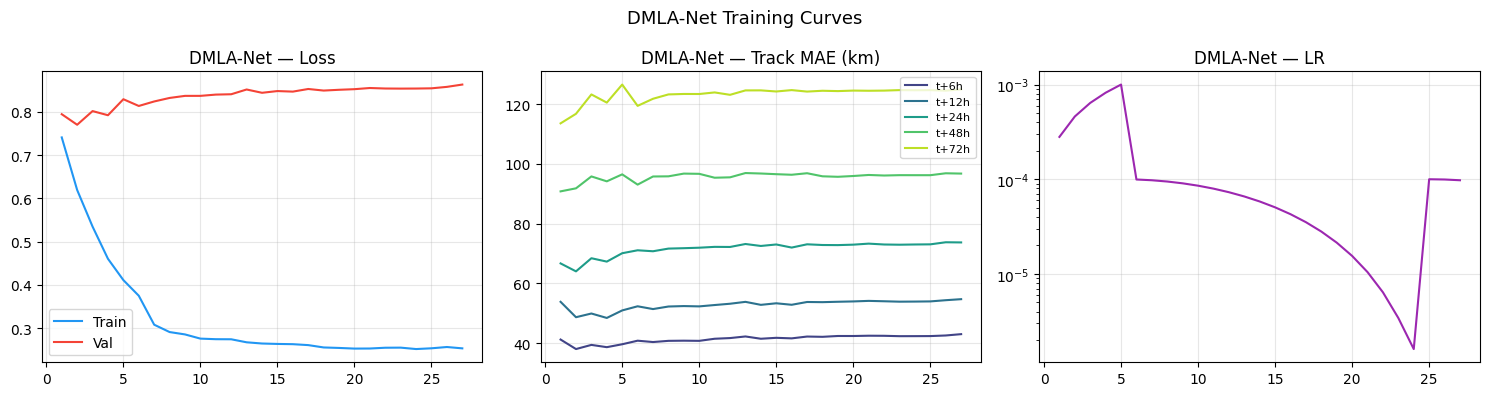

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(dmla_hist['train_total'])+1)
axes[0].plot(ep, dmla_hist['train_total'], label='Train', color='#2196F3')
axes[0].plot(ep, dmla_hist['val_total'],   label='Val',   color='#F44336')
axes[0].set_title('DMLA-Net — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
colors_h = plt.cm.viridis(np.linspace(0.2, 0.9, N_HOR))
for i, h in enumerate(HORIZONS_H):
    axes[1].plot(ep, dmla_hist[f't{h}h_km'], label=f't+{h}h', color=colors_h[i])
axes[1].set_title('DMLA-Net — Track MAE (km)'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[2].plot(ep, dmla_hist['lr'], color='#9C27B0')
axes[2].set_title('DMLA-Net — LR'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)
plt.suptitle('DMLA-Net Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR/'p3_dmlanet_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
# PHẦN 4 — Bi-LSTM + Transformer (Baseline)

In [27]:
# ── Bi-LSTM + Transformer Definition ─────────────────────────────────────────

class BiLSTM_Transformer(nn.Module):
    """
    Baseline: Bi-LSTM (2 layers) → Transformer Encoder (Pre-norm)
    """
    def __init__(
        self,
        f_in   : int   = 27,
        lstm_h : int   = 128,
        lstm_l : int   = 2,
        d_model: int   = 256,
        n_heads: int   = 8,
        n_tf   : int   = 2,
        n_hor  : int   = 5,
        n_cls  : int   = 7,
        drop   : float = 0.2,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            f_in, lstm_h, lstm_l,
            batch_first=True, bidirectional=True,
            dropout=drop if lstm_l > 1 else 0.0
        )
        self.lstm_norm = nn.LayerNorm(lstm_h * 2)
        self.proj      = nn.Linear(lstm_h * 2, d_model)
        self.pos_emb   = nn.Embedding(512, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4, dropout=drop,
            batch_first=True, activation='gelu',
            norm_first=True,   # Pre-norm (ổn định hơn)
        )
        self.tf      = nn.TransformerEncoder(enc_layer, num_layers=n_tf)
        self.tf_norm = nn.LayerNorm(d_model)

        self.heads = OutputHeads(d_model, n_hor, n_cls, drop)

    def forward(self, x: torch.Tensor) -> dict:
        B, W, _ = x.shape

        # Bi-LSTM
        o, _    = self.lstm(x)             # [B, W, lstm_h*2]
        o       = self.lstm_norm(o)

        # Project + Positional Encoding
        h = self.proj(o)                   # [B, W, d_model]
        h = h + self.pos_emb(torch.arange(W, device=x.device))

        # Transformer Encoder
        h = self.tf_norm(self.tf(h))       # [B, W, d_model]

        # Context: last timestep
        ctx = h[:, -1, :]                  # [B, d_model]

        return self.heads(ctx)   # dict: track, wind, pressure, class_logits


print('Bi-LSTM+Transformer defined OK')


Bi-LSTM+Transformer defined OK


In [28]:
bilstm_model = BiLSTM_Transformer(
    f_in=F_IN, lstm_h=128, lstm_l=2, d_model=256,
    n_heads=8, n_tf=2, n_hor=N_HOR, n_cls=N_CLASS, drop=0.2
)
verify_model_output(bilstm_model, 'Bi-LSTM+Transformer')


=== Verify model: Bi-LSTM+Transformer ===
  Output type: <class 'dict'>
  Keys       : {'pressure', 'wind', 'track', 'class_logits'}
  ✓ track         : (4, 5, 2)            (expected (4, 5, 2))
  ✓ wind          : (4, 5)               (expected (4, 5))
  ✓ pressure      : (4, 5)               (expected (4, 5))
  ✓ class_logits  : (4, 5, 7)            (expected (4, 5, 7))
  Params: 2.41M
  → Model OK! Sẵn sàng train.


True

In [29]:
bilstm_hist = run_training(
    model       = bilstm_model,
    model_name  = 'Bi-LSTM+Transformer',
    n_epochs    = 150, lr=1e-4, patience=25,
    warmup_epochs=5, T0=20,
)
ALL_RESULTS['Bi-LSTM+Transformer'] = bilstm_hist


=== Verify model: Bi-LSTM+Transformer ===
  Output type: <class 'dict'>
  Keys       : {'pressure', 'wind', 'track', 'class_logits'}
  ✓ track         : (4, 5, 2)            (expected (4, 5, 2))
  ✓ wind          : (4, 5)               (expected (4, 5))
  ✓ pressure      : (4, 5)               (expected (4, 5))
  ✓ class_logits  : (4, 5, 7)            (expected (4, 5, 7))
  Params: 2.41M
  → Model OK! Sẵn sàng train.

Training Bi-LSTM+Transformer | 150 epochs | lr=0.0001 | patience=25
Checkpoint → models\Bi_LSTM_Transformer_best.pt
──────────────────────────────────────────────────────────────────────────────
   Ep    Train      Val     t+6h    t+24h    t+72h         LR    Time
──────────────────────────────────────────────────────────────────────────────
    1 [WU]  0.7525   0.7680     40.0     62.9    113.6   2.80e-04    0.1m ← best
    2 [WU]  0.6515   0.7470     37.3     63.0    112.1   4.60e-04    0.1m ← best
    3 [WU]  0.5869   0.7758     37.6     65.4    117.9   6.40e-04    0.1

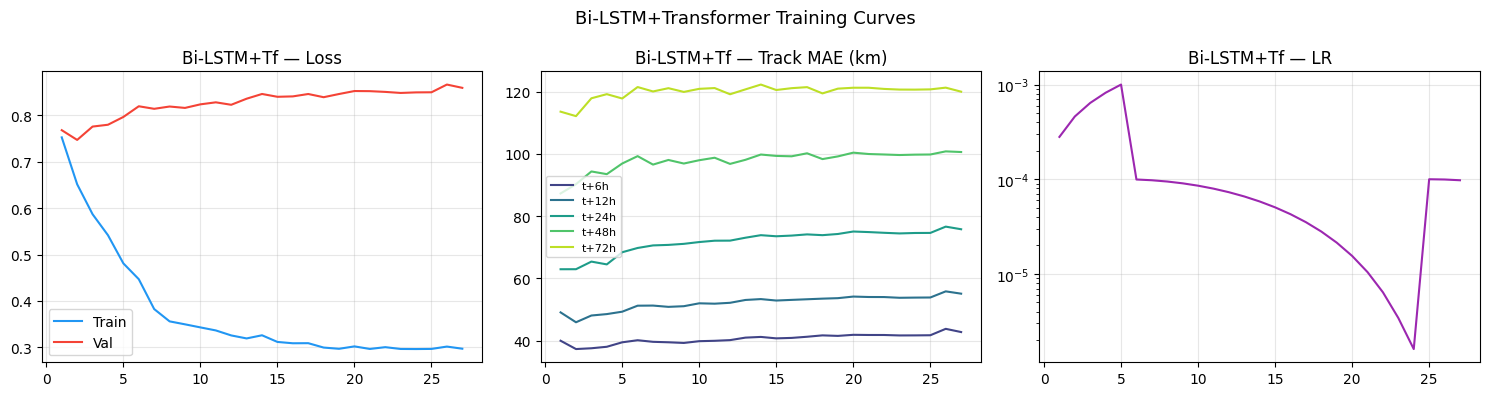

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(bilstm_hist['train_total'])+1)
axes[0].plot(ep, bilstm_hist['train_total'], label='Train', color='#2196F3')
axes[0].plot(ep, bilstm_hist['val_total'],   label='Val',   color='#F44336')
axes[0].set_title('Bi-LSTM+Tf — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
colors_h = plt.cm.viridis(np.linspace(0.2, 0.9, N_HOR))
for i, h in enumerate(HORIZONS_H):
    axes[1].plot(ep, bilstm_hist[f't{h}h_km'], label=f't+{h}h', color=colors_h[i])
axes[1].set_title('Bi-LSTM+Tf — Track MAE (km)'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[2].plot(ep, bilstm_hist['lr'], color='#9C27B0')
axes[2].set_title('Bi-LSTM+Tf — LR'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)
plt.suptitle('Bi-LSTM+Transformer Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR/'p4_bilstm_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
# PHẦN 5 — So sánh kết quả

> Chạy sau khi đã train ít nhất 1 model.

In [31]:
# ── Bảng kết quả per-horizon ──────────────────────────────────────────────────
if not ALL_RESULTS:
    print('Chưa có kết quả nào! Hãy chạy ít nhất 1 Phần (1/2/3/4).')
else:
    rows = []
    for name, hist in ALL_RESULTS.items():
        row = {
            'Model'    : name,
            'Val Loss' : f"{hist['best_val']:.4f}",
            'Epochs'   : len(hist['train_total']),
            'Time(min)': f"{hist['total_time_min']:.1f}",
        }
        for h in HORIZONS_H:
            vals = hist.get(f't{h}h_km', [])
            row[f't+{h}h(km)'] = f'{min(vals):.1f}' if vals else 'N/A'
        rows.append(row)

    df_res = pd.DataFrame(rows)
    print('=== KẾT QUẢ SO SÁNH ===')
    display(df_res)

    print('\nPersistence baseline (dự đoán = đứng yên, avg speed=20km/h):')
    for h in HORIZONS_H:
        print(f'  t+{h:2d}h: ~{20*h:.0f} km')

    if len(ALL_RESULTS) > 1:
        best_name = min(ALL_RESULTS, key=lambda n: ALL_RESULTS[n]['best_val'])
        print(f'\n→ Model tốt nhất: {best_name}')


=== KẾT QUẢ SO SÁNH ===


,Model,Val Loss,Epochs,Time(min),t+6h(km),t+12h(km),t+24h(km),t+48h(km),t+72h(km)
0,CRAN,0.7938,26,3.5,40.8,50.3,67.0,90.8,112.2
1,ST-MSRN,0.7780,28,1.6,37.2,48.4,63.0,89.7,114.1
2,DMLA-Net,0.7702,27,1.1,38.0,48.4,64.0,90.8,113.5
3,Bi-LSTM+Transformer,0.7470,27,1.6,37.3,45.9,62.9,87.3,112.1



Persistence baseline (dự đoán = đứng yên, avg speed=20km/h):
  t+ 6h: ~120 km
  t+12h: ~240 km
  t+24h: ~480 km
  t+48h: ~960 km
  t+72h: ~1440 km

→ Model tốt nhất: Bi-LSTM+Transformer


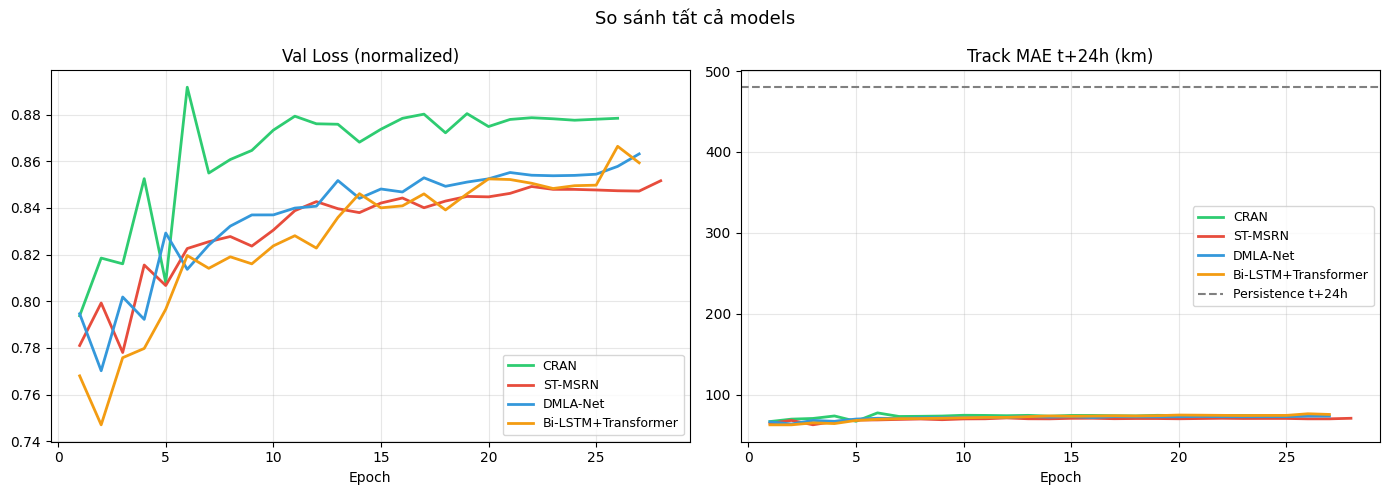

In [32]:
# ── So sánh val loss ─────────────────────────────────────────────────────────
if ALL_RESULTS:
    COLORS = {
        'CRAN'               : '#2ecc71',
        'ST-MSRN'            : '#e74c3c',
        'DMLA-Net'           : '#3498db',
        'Bi-LSTM+Transformer': '#f39c12',
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, hist in ALL_RESULTS.items():
        ep   = range(1, len(hist['train_total'])+1)
        clr  = COLORS.get(name, '#888888')
        axes[0].plot(ep, hist['val_total'], label=name, color=clr, lw=2)
        axes[1].plot(
            ep,
            hist.get('t24h_km', [None]*len(ep)),
            label=name, color=clr, lw=2
        )

    axes[0].set_title('Val Loss (normalized)'); axes[0].set_xlabel('Epoch')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    axes[1].axhline(20*24, color='gray', ls='--', lw=1.5, label='Persistence t+24h')
    axes[1].set_title('Track MAE t+24h (km)'); axes[1].set_xlabel('Epoch')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    plt.suptitle('So sánh tất cả models', fontsize=13)
    plt.tight_layout()
    plt.savefig(PLOT_DIR/'p5_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


In [33]:
# ── Lưu kết quả ──────────────────────────────────────────────────────────────
if ALL_RESULTS:
    summary = {}
    for name, hist in ALL_RESULTS.items():
        summary[name] = {
            'best_val'    : float(hist['best_val']),
            'n_epochs'    : len(hist['train_total']),
            'time_min'    : float(hist['total_time_min']),
            'per_horizon' : {
                f't+{h}h_km': float(min(hist[f't{h}h_km']))
                for h in HORIZONS_H
                if hist.get(f't{h}h_km')
            }
        }
    out_path = MODEL_DIR / 'training_results.json'
    out_path.write_text(json.dumps(summary, indent=2))
    print(f'Đã lưu → {out_path}')

    print()
    print('='*60)
    print('  TỔNG KẾT NOTEBOOK 4.0')
    print('='*60)
    for name, s in summary.items():
        ph = s['per_horizon']
        print(f'  {name}')
        print(f'    Val Loss : {s["best_val"]:.4f}')
        print(f'    Epochs   : {s["n_epochs"]}')
        print(f'    t+6h     : {ph.get("t+6h_km","N/A")}')
        print(f'    t+24h    : {ph.get("t+24h_km","N/A")}')
        print(f'    t+72h    : {ph.get("t+72h_km","N/A")}')
        print()
    print('→ Notebook 5.0: Evaluation chi tiết trên Test Set')
    print('='*60)


Đã lưu → models\training_results.json

  TỔNG KẾT NOTEBOOK 4.0
  CRAN
    Val Loss : 0.7938
    Epochs   : 26
    t+6h     : 40.774810791015625
    t+24h    : 66.9991226196289
    t+72h    : 112.16485595703125

  ST-MSRN
    Val Loss : 0.7780
    Epochs   : 28
    t+6h     : 37.20479965209961
    t+24h    : 63.03102493286133
    t+72h    : 114.0750503540039

  DMLA-Net
    Val Loss : 0.7702
    Epochs   : 27
    t+6h     : 38.011898040771484
    t+24h    : 64.01020812988281
    t+72h    : 113.5403060913086

  Bi-LSTM+Transformer
    Val Loss : 0.7470
    Epochs   : 27
    t+6h     : 37.30430221557617
    t+24h    : 62.94505310058594
    t+72h    : 112.12752532958984

→ Notebook 5.0: Evaluation chi tiết trên Test Set
